In [407]:
import numpy as np
import matplotlib.pyplot as plt

# loading data
age, pcb = np.loadtxt('PCB.dt', unpack=True)
print("Ages:", age)
print("PCB Concentrations:", pcb)

Ages: [ 1.  6.  1.  6.  1.  6.  1.  7.  2.  7.  2.  7.  2.  8.  3.  8.  3.  8.
  3.  9.  4. 11.  4. 12.  4. 12.  5. 12.]
PCB Concentrations: [ 0.6  3.4  1.6  9.7  0.5  8.6  1.2  4.   2.   5.5  1.3 10.5  2.5 17.5
  2.2 13.4  2.4  4.5  1.2 30.4  3.5 12.4  4.1 13.4  5.1 26.2  5.7  7.4]


Tasl 1

In [408]:
def Linear_Regression(X,y):
    # Ensures X has at least 2 dimension (column vector)
    # e.i turns X.shape = (28, ) into (28, 1)
    X = np.atleast_2d(X).T
    N, d = X.shape

    # argument the data matrix with 1^N vector
    ones = np.ones((N, 1))
    X_arg = np.hstack([X, ones])

    # find the pseudoinverse X† = (X^T X)^-1 X^T
    # the easy way is np.linalg.pinv(X_arg)
    pseudoinverse = np.linalg.inv(X_arg.T @ X_arg) @ X_arg.T

    # returns (𝑤_1,..., 𝑤_𝑑, 𝑏)^T = X†𝒚
    return pseudoinverse @ y

# linear
a_linear,b_linear = Linear_Regression(age, pcb)
print("task 1, w = (a,b):", a_linear,b_linear)

# for non-linear, simply apply log to target (y)
# and the model is h(x)= exp(ax+b) 
# remember that last val in w is b
pcb_log_real = np.log(pcb)

# non linear
a_non,b_non = Linear_Regression(age, pcb_log_real)
print("task 2, w = (a,b):", a_non,b_non)

# the linear model
def h_prime(x, a, b):
    return a*x + b

# the non-linear model
def h(x, a, b):
    return np.exp(h_prime(x, a, b))

# doesn't actually matter in which order the predicted/real values go
def squared_error_sum(y_real,y_pred):
    return (y_real-y_pred) @ (y_real-y_pred)

# with the model, we can now calc MSE
# First compute the total error
pcb_pred = h(age, a_non, b_non)
error = squared_error_sum(pcb, pcb_pred)
print("squared error is:", error)

# Now we get the mean error
N = len(age)
print("MSE:", 1/N * error)

task 1, w = (a,b): 1.5577705194394684 -1.4519439468970607
task 2, w = (a,b): 0.2591282395640714 0.031472469714475815
squared error is: 975.3957126821697
MSE: 34.83556116722034


Task 3

In [409]:
# Selecting the data set S from 2 data points
print("Ages:", age[[23, 27]])
print("PCB Concentrations:", pcb[[23, 27]])
S_X = age[[23, 27]]
S_Y = pcb[[23, 27]]

h_SX = h(S_X, a_non, b_non)
h_prime_SX = h_prime(S_X, a_linear, b_linear)
print(a_linear, b_linear)
log_SY = np.log(S_Y)
print('h(x)', h_SX)
print("h'(x)", h_prime_SX)
print("log(y)", log_SY)

# (y - h(x))^2
print("LHS:", squared_error_sum(S_Y,h_SX))
# (ln y - h'(x))^2
print("RHS:", squared_error_sum(log_SY,h_prime_SX))

Ages: [12. 12.]
PCB Concentrations: [13.4  7.4]
1.5577705194394684 -1.4519439468970607
h(x) [23.12724465 23.12724465]
h'(x) [17.24130229 17.24130229]
log(y) [2.59525471 2.00148   ]
LHS: 341.965512584701
RHS: 446.75889301256063


Task 4

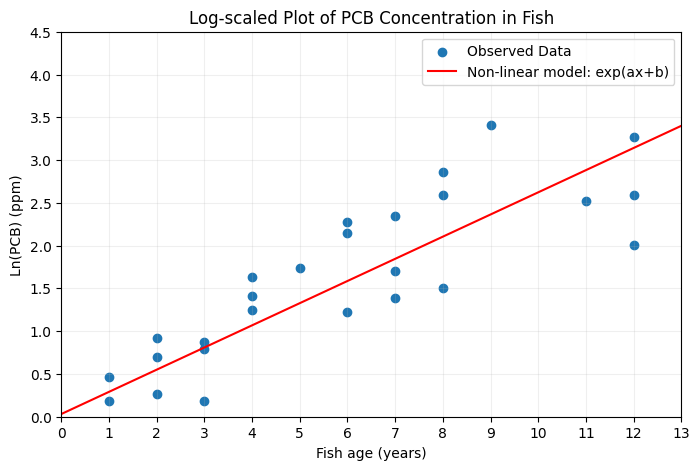

In [410]:
#time to plot the graphs, log of PCB vs age
# our prediction model, we log scale the prediction
x = np.arange(0, 14, 1)
y = np.log(h(x, a_non, b_non))

# Initialise figure (fig) and axis (ax)
fig, ax = plt.subplots(figsize=(8,5))

# Set labels and title
ax.set_xlabel('Fish age (years)')
ax.set_ylabel('Ln(PCB) (ppm)')
ax.set_title('Log-scaled Plot of PCB Concentration in Fish')

# Add grid
ax.grid(alpha=0.2)

# Set axes limits
ax.set_xlim(0,13)
ax.set_ylim(0,4.5)

# Set custom ticks for x and y axes
ax.set_xticks(np.arange(0, 14, 1))  # Add more x-axis gridlines
ax.set_yticks(np.arange(0, 5, 0.5))  # Add more y-axis gridlines

# plot the data points on log scale
plt.scatter(age, pcb_log_real, label="Observed Data")

# Plot in the prediction model, add label to data
ax.plot(x, y, label='Non-linear model: exp(ax+b)', color='red')
# Add legend
ax.legend()

# Show plot
plt.show()

Task 5

In [411]:
# Compute the coefficient of determination

# residuals sum of squares, RSS
# Sum i=1 to N, (y_i - h(x_i))^2
# NOTE REMEMBER TO SCALE PREDICTION TO LOG
RSS = squared_error_sum(pcb_log_real, np.log(h(age, a_non, b_non)))
print("RSS:", RSS)

# total sum of squares, TSS
# Sum i=1 to N, (y_i - y_mean)^2
TSS = squared_error_sum(pcb_log_real, np.mean(pcb_log_real))
print("TSS:", TSS)

print("R^2:", 1-(RSS/TSS))

RSS: 8.358977897028133
TSS: 31.11956347292473
R^2: 0.7313915439623445


Task 6

1.1986063028078175 -1.1947508236636466
Squared error is: 786.3629248984425
MSE: 28.084390174944375


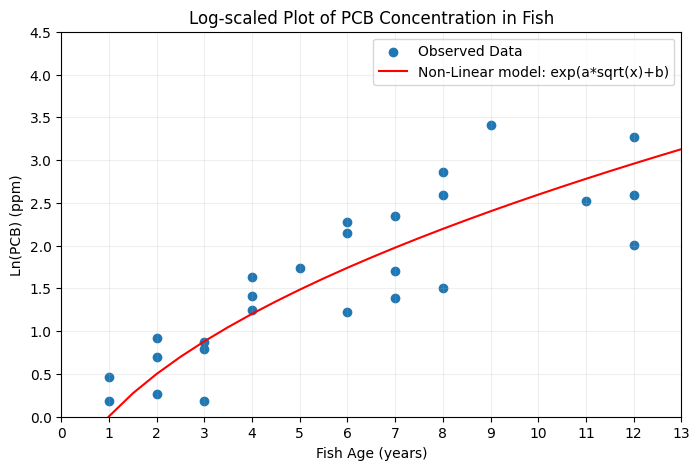

In [412]:
# transform x, x-> sqrt(x), then map a linear model 
# onto our transformed targets
a2, b2 = Linear_Regression(np.sqrt(age), pcb_log_real)
print(a2, b2)

# our final non-linear model
def h2(x, a, b):
    return np.exp(a * np.sqrt(x) + b)

# we calc the error of this new non linear model
error2 = squared_error_sum(pcb, h2(age, a2, b2))
print("Squared error is:", error2)
print("MSE:", 1/N * error2)

# now we can build and plot our non-linear model
x = np.arange(0, 14, 0.5)
# remember to log scale the prediction
y = np.log(h2(x, a2, b2))

# Initialise figure (fig) and axis (ax)
fig, ax = plt.subplots(figsize=(8,5))

# Set labels and title
ax.set_xlabel('Fish Age (years)')
ax.set_ylabel('Ln(PCB) (ppm)')
ax.set_title('Log-scaled Plot of PCB Concentration in Fish')

# Add grid
ax.grid(alpha=0.2)

# Set axes limits
ax.set_xlim(0,6)
ax.set_ylim(0,4.5)

# Set custom ticks for x and y axes
ax.set_xticks(np.arange(0, 14, 1))  # Add more x-axis gridlines
ax.set_yticks(np.arange(0, 5, 0.5))  # Add more y-axis gridlines

#  plot the target on logarithmic scale and the model output over the original inputs 
plt.scatter(age, pcb_log_real, label="Observed Data")

# Plot in the prediction model, add label to data
ax.plot(x, y, label='Non-Linear model: exp(a*sqrt(x)+b)', color='red')
# Add legend
ax.legend()

# Show plot
plt.show()

In [413]:
# residuals sum of squares, RSS
# Sum i=1 to N, (y_i - h(x_i))^2
# NOTE REMEMBER TO SCALE PREDICTION TO LOG
RSS = squared_error_sum(pcb_log_real, np.log(h2(age, a2, b2)))
print("RSS:", RSS)

# total sum of squares, TSS
# Sum i=1 to N, (y_i - y_mean)^2
TSS = squared_error_sum(pcb_log_real, np.mean(pcb_log_real))
print("TSS:", TSS)

print("R^2:", 1-(RSS/TSS))

RSS: 6.656298952813462
TSS: 31.11956347292473
R^2: 0.7861056451320498
